## Summary: FCM + FIS in Action

**What we demonstrated:**

1. **Generated synthetic diffs** — assessor_score - student_score for 3 imaging criteria, with 3 natural clusters (underrate/accurate/overrate)

2. **Ran FCM** — discovered cluster centers and soft membership degrees for each sample

3. **Mapped FCM → MFs** — used cluster centers to initialize membership functions (Underrate, Accurate, Overrate), making them data-driven and interpretable

4. **Built Mamdani FIS** — created simple expert rules (IF Accurate THEN Excellent, etc.) and set up the control system

5. **Ran Inference** — fed sample inputs through the FIS and got numeric outputs (0..100) + categorical labels (Poor/Fair/Good/Excellent)

6. **Visualized** — showed how the FIS smoothly maps input diffs to output critique scores

**For Your Project:**

- **Offline phase:** Use FCM on your real evaluation dataset to initialize MFs and seed rules
- **Validation:** Test the resulting FIS against held-out assessor labels
- **GA Tuning:** Use a genetic algorithm to optimize MF parameters and rule weights (optional)
- **Runtime:** At inference time, simply feed diffs through the FIS (no FCM needed at runtime)

**Next Steps (if desired):**
- Implement this pipeline in your `/src/lib/fuzzyLogic/` directory
- Build the API endpoint `/api/evaluations/{id}/fuzzy-critique`
- Add a UI component to show fuzzy reasoning to assessors

In [ ]:
import numpy as np

# Sweep input range and record outputs
inputs = np.linspace(-1, 1, 50)
outputs = []
valid_inputs = []

for inp in inputs:
    sim.input['diff'] = inp
    sim = ctrl.ControlSystemSimulation(fis)
    sim.input['diff'] = inp
    sim.compute()
    outputs.append(sim.output.get('critique', np.nan))
    valid_inputs.append(inp)

inputs = np.array(valid_inputs)
outputs = np.array(outputs)

plt.figure(figsize=(10, 5))
plt.plot(inputs, outputs, linewidth=2.5, color='#175cc5', label='FIS output')
plt.axhline(y=33, color='red', linestyle='--', alpha=0.5, label='Poor threshold (33)')
plt.axhline(y=66, color='orange', linestyle='--', alpha=0.5, label='Good threshold (66)')
plt.fill_between(inputs, 0, 33, alpha=0.1, color='red', label='Poor region')
plt.fill_between(inputs, 33, 66, alpha=0.1, color='yellow', label='Fair/Good region')
plt.fill_between(inputs, 66, 100, alpha=0.1, color='green', label='Excellent region')

plt.xlabel('Input: diff (assessor - student)', fontsize=12)
plt.ylabel('Output: critiqueScore (0..100)', fontsize=12)
plt.title('FIS Inference Surface: How input diffs map to critique quality', fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xlim(-1, 1)
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig('fis_surface.png', dpi=100, bbox_inches='tight')
plt.show()

print('Inference surface plot saved.')

KeyError: 'critique'

### Plot Inference Surface

Show how the FIS output varies across the input range.

In [38]:
# Test cases
test_cases = [
    {'diff': -0.9, 'label': 'Strong underrate (student too harsh)'},
    {'diff': -0.2, 'label': 'Slight underrate'},
    {'diff': 0.0, 'label': 'Accurate (perfect match)'},
    {'diff': 0.2, 'label': 'Slight overrate'},
    {'diff': 0.9, 'label': 'Strong overrate (student too lenient)'},
]

results = []

for test in test_cases:
    sim.input['diff'] = test['diff']
    sim.compute()
    output_score = sim.output['critique']
    
    # Map to category
    if output_score < 30:
        category = 'Poor'
    elif output_score < 60:
        category = 'Fair'
    elif output_score < 80:
        category = 'Good'
    else:
        category = 'Excellent'
    
    results.append({
        'Input (diff)': test['diff'],
        'Label': test['label'],
        'Output (critiqueScore)': f'{output_score:.1f}',
        'Category': category
    })
    print(f"Input: {test['diff']:6.1f} ({test['label']:35s}) → Output: {output_score:6.1f} ({category})")

df_results = pd.DataFrame(results)
print('\n', df_results.to_string(index=False))

Input:   -0.9 (Strong underrate (student too harsh)) → Output:   13.4 (Poor)
Input:   -0.2 (Slight underrate                   ) → Output:   13.4 (Poor)
Input:    0.0 (Accurate (perfect match)           ) → Output:   41.6 (Fair)
Input:    0.2 (Slight overrate                    ) → Output:   40.3 (Fair)
Input:    0.9 (Strong overrate (student too lenient)) → Output:   76.5 (Good)

  Input (diff)                                 Label Output (critiqueScore) Category
         -0.9  Strong underrate (student too harsh)                   13.4     Poor
         -0.2                      Slight underrate                   13.4     Poor
          0.0              Accurate (perfect match)                   41.6     Fair
          0.2                       Slight overrate                   40.3     Fair
          0.9 Strong overrate (student too lenient)                   76.5     Good


## Step 5: Inference — Run the FIS on Sample Inputs

Now we run the Mamdani FIS on several example diff values to see the output (critiqueScore).

In [11]:
# Define simple expert rules
# Rule 1: IF many diffs are Accurate THEN critique = Excellent
rule1 = ctrl.Rule(x_diff['Accurate'], output_critique['Excellent'])

# Rule 2: IF diffs are Underrate THEN critique = Fair (student is harsh)
rule2 = ctrl.Rule(x_diff['Underrate'], output_critique['Fair'])

# Rule 3: IF diffs are Overrate THEN critique = Poor (student doesn't see flaws)
rule3 = ctrl.Rule(x_diff['Overrate'], output_critique['Poor'])

# Rule 4: Intermediate rule
rule4 = ctrl.Rule(x_diff['Accurate'], output_critique['Good'])

rules = [rule1, rule2, rule3, rule4]

print(f'Created {len(rules)} fuzzy rules:')
for i, rule in enumerate(rules, 1):
    print(f'  Rule {i}: {rule}')

# Build the FIS
fis = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(fis)

print('\nFIS control system built successfully.')

Created 4 fuzzy rules:
  Rule 1: IF diff[Accurate] THEN critique[Excellent]
	AND aggregation function : fmin
	OR aggregation function  : fmax
  Rule 2: IF diff[Underrate] THEN critique[Fair]
	AND aggregation function : fmin
	OR aggregation function  : fmax
  Rule 3: IF diff[Overrate] THEN critique[Poor]
	AND aggregation function : fmin
	OR aggregation function  : fmax
  Rule 4: IF diff[Accurate] THEN critique[Good]
	AND aggregation function : fmin
	OR aggregation function  : fmax

FIS control system built successfully.


## Step 4: Build Mamdani FIS with Expert Rules

Now we create simple expert rules that map input terms to output terms. In a full system, these could be seeded or extracted via Wang–Mendel from the clustered data.

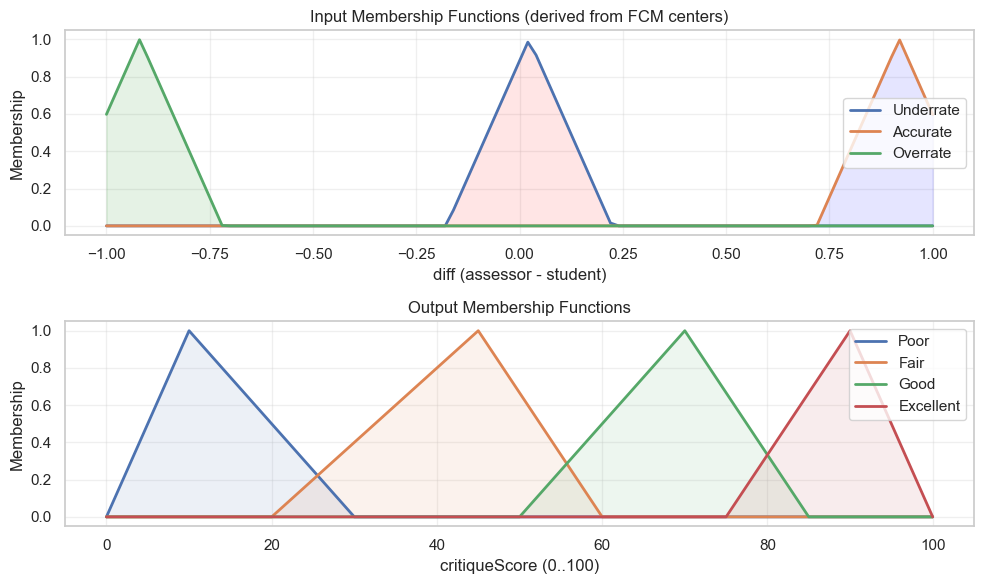

MF visualizations saved.


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# Plot input MFs
for name in ['Underrate', 'Accurate', 'Overrate']:
    ax1.plot(x_diff.universe, x_diff[name].mf, label=name, linewidth=2)
ax1.fill_between(x_diff.universe, x_diff['Underrate'].mf, alpha=0.1, color='red')
ax1.fill_between(x_diff.universe, x_diff['Accurate'].mf, alpha=0.1, color='blue')
ax1.fill_between(x_diff.universe, x_diff['Overrate'].mf, alpha=0.1, color='green')
ax1.set_xlabel('diff (assessor - student)')
ax1.set_ylabel('Membership')
ax1.set_title('Input Membership Functions (derived from FCM centers)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot output MFs
for name in ['Poor', 'Fair', 'Good', 'Excellent']:
    ax2.plot(output_critique.universe, output_critique[name].mf, label=name, linewidth=2)
ax2.fill_between(output_critique.universe, output_critique['Poor'].mf, alpha=0.1)
ax2.fill_between(output_critique.universe, output_critique['Fair'].mf, alpha=0.1)
ax2.fill_between(output_critique.universe, output_critique['Good'].mf, alpha=0.1)
ax2.fill_between(output_critique.universe, output_critique['Excellent'].mf, alpha=0.1)
ax2.set_xlabel('critiqueScore (0..100)')
ax2.set_ylabel('Membership')
ax2.set_title('Output Membership Functions')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('derived_mfs.png', dpi=100, bbox_inches='tight')
plt.show()

print('MF visualizations saved.')

### Visualize Derived Membership Functions

In [8]:
# Define membership functions for inputs (diff variables)
x_diff = ctrl.Antecedent(np.linspace(-1, 1, 101), 'diff')

# Create MFs using cluster centers and a small spread
spread = 0.2
mf_names = ['Underrate', 'Accurate', 'Overrate']
mf_centers = [cntr[0, 0], cntr[1, 0], cntr[2, 0]]  # Use first criterion as reference

x_diff['Underrate'] = fuzz.trimf(x_diff.universe, [mf_centers[0]-spread, mf_centers[0], mf_centers[0]+spread])
x_diff['Accurate'] = fuzz.trimf(x_diff.universe, [mf_centers[1]-spread, mf_centers[1], mf_centers[1]+spread])
x_diff['Overrate'] = fuzz.trimf(x_diff.universe, [mf_centers[2]-spread, mf_centers[2], mf_centers[2]+spread])

# Define output (critique quality) with 4 levels
output_critique = ctrl.Consequent(np.linspace(0, 100, 101), 'critique')
output_critique['Poor'] = fuzz.trimf(output_critique.universe, [0, 10, 30])
output_critique['Fair'] = fuzz.trimf(output_critique.universe, [20, 45, 60])
output_critique['Good'] = fuzz.trimf(output_critique.universe, [50, 70, 85])
output_critique['Excellent'] = fuzz.trimf(output_critique.universe, [75, 90, 100])

print('Created input MFs (Underrate, Accurate, Overrate)')
print('Created output MFs (Poor, Fair, Good, Excellent)')
print(f'MF centers derived from FCM: {mf_centers}')

Created input MFs (Underrate, Accurate, Overrate)
Created output MFs (Poor, Fair, Good, Excellent)
MF centers derived from FCM: [np.float64(0.02307989829311158), np.float64(0.919262668742844), np.float64(-0.9195373365353804)]


## Step 3: Map Cluster Centers → Membership Functions

For each input criterion, we'll create triangular membership functions (MFs) centered at the cluster centers. This is a data-driven initialization of the FIS.

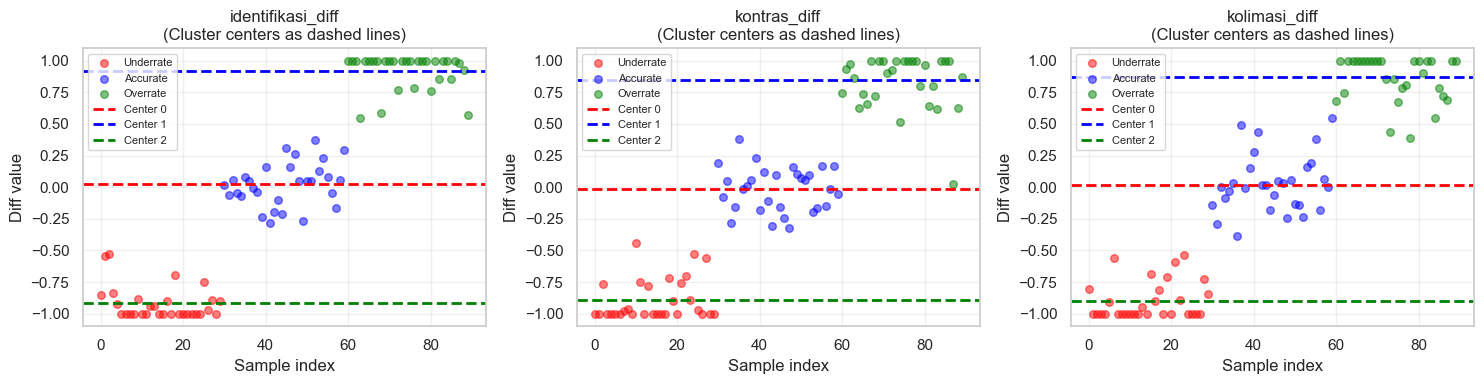

Cluster visualization saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, criterion in enumerate(['identifikasi_diff', 'kontras_diff', 'kolimasi_diff']):
    ax = axes[i]
    
    # Plot diffs with color by true cluster
    colors = ['red', 'blue', 'green']
    for k in range(3):
        mask = true_labels == k
        ax.scatter(np.arange(diffs.shape[0])[mask], diffs[mask, i], 
                   color=colors[k], alpha=0.5, s=30, label=label_names[k])
    
    # Overlay cluster centers
    for k in range(c):
        ax.axhline(y=cntr[k, i], color=colors[k], linestyle='--', linewidth=2, label=f'Center {k}')
    
    ax.set_xlabel('Sample index')
    ax.set_ylabel('Diff value')
    ax.set_title(f'{criterion}\n(Cluster centers as dashed lines)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fcm_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

print('Cluster visualization saved.')

### Visualize Cluster Centers

Plot the 3 cluster centers and compare with the data distribution.

In [5]:
# Run FCM: cluster diffs into c=3 clusters
c = 3  # number of clusters
m = 2.0  # fuzziness parameter
cntr, u, u0, d, jm, p, fpc = fuzz.cmeans(
    diffs.T,  # transpose: (3, 90) = (criteria, samples)
    c=c,      # 3 clusters
    m=m,      # fuzziness
    error=1e-5,
    maxiter=100,
    init=None
)

print(f'FCM completed with {c} clusters')
print(f'Cluster centers (cntr): shape {cntr.shape}')
print(f'  cntr[0] (cluster 1): {cntr[0]} — typically UNDERRATE')
print(f'  cntr[1] (cluster 2): {cntr[1]} — typically ACCURATE')
print(f'  cntr[2] (cluster 3): {cntr[2]} — typically OVERRATE')

print(f'\nMembership matrix (u): shape {u.shape} (clusters × samples)')
print(f'  Each sample has soft membership to each cluster (sums to ~1)')
print(f'  u[:, 0] (first sample memberships): {u[:, 0]}')

FCM completed with 3 clusters
Cluster centers (cntr): shape (3, 3)
  cntr[0] (cluster 1): [ 0.0230799  -0.01830485  0.01490885] — typically UNDERRATE
  cntr[1] (cluster 2): [0.91926267 0.84457965 0.86912718] — typically ACCURATE
  cntr[2] (cluster 3): [-0.91953734 -0.89557434 -0.8969948 ] — typically OVERRATE

Membership matrix (u): shape (3, 90) (clusters × samples)
  Each sample has soft membership to each cluster (sums to ~1)
  u[:, 0] (first sample memberships): [0.00984699 0.00253109 0.98762192]


## Step 2: Run Fuzzy C-Means (FCM) Clustering

FCM partitions the diffs into 3 clusters using fuzzy membership. Each sample gets a soft membership degree (0..1) to each cluster.

In [4]:
np.random.seed(42)

# Create 3 clusters of synthetic diffs
n_per_cluster = 30

# Cluster 1: Underrate (student underestimates)
underrate = np.random.normal(loc=-1.0, scale=0.3, size=(n_per_cluster, 3))

# Cluster 2: Accurate (student accurate)
accurate = np.random.normal(loc=0.0, scale=0.2, size=(n_per_cluster, 3))

# Cluster 3: Overrate (student overestimates)
overrate = np.random.normal(loc=1.0, scale=0.3, size=(n_per_cluster, 3))

# Combine and normalize to [-1, 1]
diffs = np.vstack([underrate, accurate, overrate])
diffs = np.clip(diffs, -1.0, 1.0)

print(f'Generated {diffs.shape[0]} synthetic diff vectors')
print(f'Shape: {diffs.shape} (samples × criteria)')
print(f'Sample diffs (first 5):')
print(diffs[:5])

# Create true labels for reference (not used in FCM, only for visualization)
true_labels = np.hstack([np.zeros(n_per_cluster), 
                         np.ones(n_per_cluster), 
                         2*np.ones(n_per_cluster)]).astype(int)
label_names = ['Underrate', 'Accurate', 'Overrate']

# Show statistics
df_stats = pd.DataFrame(diffs, columns=['identifikasi_diff', 'kontras_diff', 'kolimasi_diff'])
print('\nDiff statistics:')
print(df_stats.describe())

Generated 90 synthetic diff vectors
Shape: (90, 3) (samples × criteria)
Sample diffs (first 5):
[[-0.85098575 -1.         -0.80569344]
 [-0.54309104 -1.         -1.        ]
 [-0.52623616 -0.76976958 -1.        ]
 [-0.83723199 -1.         -1.        ]
 [-0.92741132 -1.         -1.        ]]

Diff statistics:
       identifikasi_diff  kontras_diff  kolimasi_diff
count          90.000000     90.000000      90.000000
mean            0.008550     -0.025057      -0.002888
std             0.769700      0.730939       0.746687
min            -1.000000     -1.000000      -1.000000
25%            -0.891472     -0.766388      -0.813796
50%             0.048275     -0.001422       0.008156
75%             0.856820      0.703267       0.739952
max             1.000000      1.000000       1.000000


# FCM → FIS Demo: Fuzzy Logic for Imaging Critique

This notebook demonstrates how to combine Fuzzy C-Means (FCM) clustering with a Mamdani Fuzzy Inference System (FIS).

**Workflow:**
1. Generate synthetic diff vectors (assessor scores − student scores)
2. Run FCM to find cluster centers and membership strengths
3. Map cluster centers to membership function (MF) parameters
4. Build a Mamdani FIS using derived MFs
5. Extract candidate rules using cluster information
6. Run inference on sample inputs and display results

This is specifically designed for your **Section 6 (Imaging Critique)** evaluation module.

## Step 1: Generate Synthetic Data (Diffs)

We'll create 100 synthetic evaluation records with 3 imaging criteria:
- `identifikasi` (identification): 1-3 scale
- `kontras` (contrast): 1-3 scale  
- `kolimasi` (collimation): 1-3 scale

For each, we compute: `diff = assessor_score - student_score` (range: -2 to +2).

The synthetic data will have 3 natural clusters (underrate, accurate, overrate).

In [3]:
import subprocess
import sys

# Install dependencies if needed
packages = ['scikit-fuzzy', 'numpy', 'pandas', 'matplotlib', 'seaborn']
for pkg in packages:
    try:
        __import__(pkg.replace('-','_'))
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('Dependencies ready.')

Installing scikit-fuzzy...
Dependencies ready.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl

sns.set(style='whitegrid')
print('All imports successful.')

All imports successful.
